In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
import torchvision
from torchvision import transforms
import random
import json

In [37]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(19)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


#### Данные и DataLoader

In [11]:
# Определение transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузка датасета
train_full = torchvision.datasets.EMNIST(
    root='./data', 
    split='balanced', 
    train=True, 
    download=False, 
    transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', 
    split='balanced', 
    train=False, 
    download=False, 
    transform=transform
)

In [12]:
class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_dataset))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [18]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
print("Batch shapes:")
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print("Диапазоны значений:")
print(f"x_batch: min={x_batch.min():.3f}, max={x_batch.max():.3f}, mean={x_batch.mean():.3f}")
print(f"y_batch: min={y_batch.min()}, max={y_batch.max()}, unique={len(torch.unique(y_batch))} классов")

Batch shapes:
x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64
Диапазоны значений:
x_batch: min=-1.000, max=1.000, mean=-0.646
y_batch: min=0, max=46, unique=37 классов


#### Модель MLP и цикл обучения

In [22]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
     

In [32]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,           # 784 пикселя (28×28)
        hidden_dims: tuple = (256, 128), # Больше нейронов для 47 классов
        num_classes: int = 47,              # EMNIST balanced: 47 классов
        activation: str = "relu",           # ReLU по умолчанию
        dropout_p: float = 0.0,             # Dropout для регуляризации
        use_batchnorm: bool = False,        # BatchNorm опционально
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]  # 28×28 → 784

        prev = input_dim
        for h in hidden_dims:    # Для каждого скрытого слоя
            layers.append(nn.Linear(prev, h))     # Linear(prev → h)
            if use_batchnorm:                     # BatchNorm (опционально)
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())            # Активация
            if dropout_p > 0:                     # Dropout (опционально)
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [33]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [34]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1380, acc=0.6650 | val loss=0.7701, acc=0.7584
epoch 02/20 | train loss=0.6526, acc=0.7903 | val loss=0.6108, acc=0.8012
epoch 03/20 | train loss=0.5571, acc=0.8156 | val loss=0.5839, acc=0.8119
epoch 04/20 | train loss=0.5068, acc=0.8278 | val loss=0.5500, acc=0.8204
epoch 05/20 | train loss=0.4690, acc=0.8381 | val loss=0.5309, acc=0.8285
epoch 06/20 | train loss=0.4455, acc=0.8446 | val loss=0.5264, acc=0.8287
epoch 07/20 | train loss=0.4215, acc=0.8500 | val loss=0.5141, acc=0.8360
epoch 08/20 | train loss=0.4083, acc=0.8535 | val loss=0.5205, acc=0.8323
epoch 09/20 | train loss=0.3925, acc=0.8588 | val loss=0.5237, acc=0.8311
epoch 10/20 | train loss=0.3803, acc=0.8620 | val loss=0.5553, acc=0.8239
epoch 11/20 | train loss=0.3655, acc=0.8652 | val loss=0.5316, acc=0.8338
epoch 12/20 | train loss=0.3575, acc=0.8677 | val loss=0.5387, acc=0.8356
epoch 13/20 | train loss=0.3458, acc=0.8704 | val loss=0.5241, acc=0.8352
epoch 14/20 | train loss=0.3379, acc=0

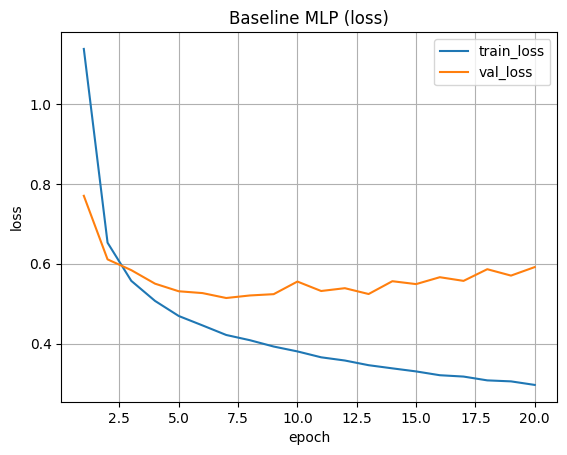

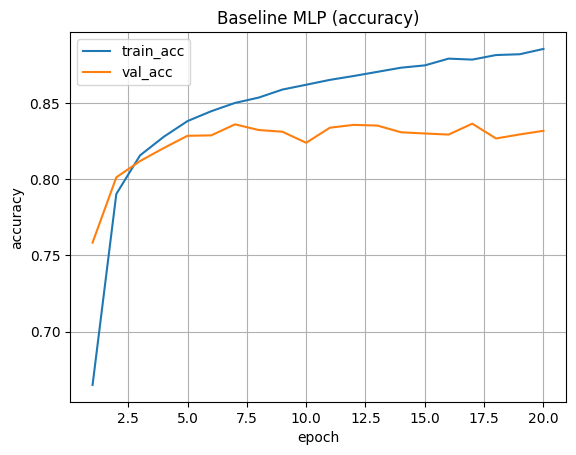

In [29]:
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [79]:
def log_experiment(
    experiment_id: str,
    dataset: str,
    model: MLP,
    history: dict,
    epochs_trained: int,
    optimizer=None,
    runs_file: str = "artifacts/runs.csv",
    seed: int | None = None,
):
    if seed is None:
        try:
            seed = torch.initial_seed() % (2**31 - 1)
        except Exception:
            seed = -1  # "неизвестный" seed

    hidden_dims = getattr(model, "hidden_dims", "unknown")
    act_name = None
    for layer in model.net:
        if isinstance(layer, (nn.ReLU, nn.Tanh, nn.GELU)):
            act_name = layer.__class__.__name__.lower()
            break
    if act_name is None:
        act_name = "unknown"
    dropout = any(isinstance(layer, nn.Dropout) for layer in model.net)
    batchnorm = any(isinstance(layer, nn.BatchNorm1d) for layer in model.net)

    model_summary = f"hidden={hidden_dims} / {act_name} / dropout={dropout} / batchnorm={batchnorm}"

    best_idx = int(np.argmax(history["val_acc"]))
    best_val_acc = float(history["val_acc"][best_idx])
    best_val_loss = float(history["val_loss"][best_idx])

    opt_info = {
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0
    }
    
    if optimizer is not None:
        # Читаем параметры из оптимизатора
        opt_info["optimizer"] = optimizer.__class__.__name__
        
        # lr из первого param_group
        if optimizer.param_groups[0].get('lr'):
            opt_info["lr"] = optimizer.param_groups[0]['lr']
        
        # momentum (только для SGD)
        if 'momentum' in optimizer.param_groups[0]:
            opt_info["momentum"] = optimizer.param_groups[0]['momentum']
        
        # weight_decay
        if optimizer.param_groups[0].get('weight_decay'):
            opt_info["weight_decay"] = optimizer.param_groups[0]['weight_decay']

    row = {
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        **opt_info,  # ← вставляем optimizer info
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
    }

    df_new = pd.DataFrame([row])
    try:
        df_existing = pd.read_csv(runs_file)
        df = pd.concat([df_existing, df_new], ignore_index=True)
    except FileNotFoundError:
        df = df_new

    df.to_csv(runs_file, index=False)
    print(f"{experiment_id} сохранён в {runs_file}, best_val_acc={best_val_acc:.4f} (epoch {best_idx+1})")

### E1 (base)

epoch 01/20 | train loss=1.1483, acc=0.6560 | val loss=0.7456, acc=0.7632
epoch 02/20 | train loss=0.6726, acc=0.7824 | val loss=0.6173, acc=0.8015
epoch 03/20 | train loss=0.5754, acc=0.8079 | val loss=0.5728, acc=0.8160
epoch 04/20 | train loss=0.5215, acc=0.8226 | val loss=0.5680, acc=0.8141
epoch 05/20 | train loss=0.4835, acc=0.8322 | val loss=0.5401, acc=0.8244
epoch 06/20 | train loss=0.4573, acc=0.8399 | val loss=0.5423, acc=0.8247
epoch 07/20 | train loss=0.4304, acc=0.8455 | val loss=0.5230, acc=0.8286
epoch 08/20 | train loss=0.4126, acc=0.8519 | val loss=0.5239, acc=0.8354
epoch 09/20 | train loss=0.3963, acc=0.8569 | val loss=0.5643, acc=0.8209
epoch 10/20 | train loss=0.3807, acc=0.8596 | val loss=0.5483, acc=0.8249
epoch 11/20 | train loss=0.3690, acc=0.8640 | val loss=0.5308, acc=0.8359
epoch 12/20 | train loss=0.3557, acc=0.8666 | val loss=0.5296, acc=0.8358
epoch 13/20 | train loss=0.3474, acc=0.8697 | val loss=0.5629, acc=0.8273
epoch 14/20 | train loss=0.3359, acc=0

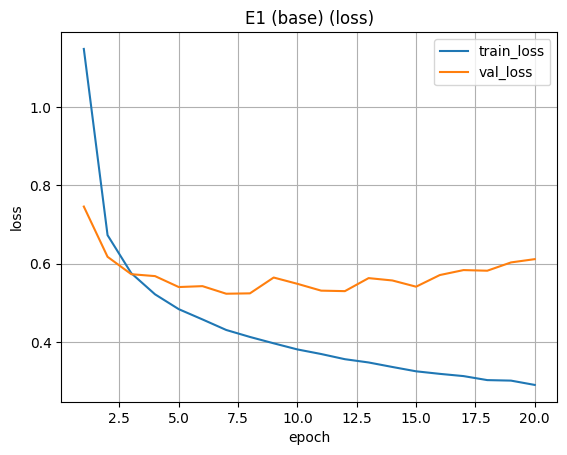

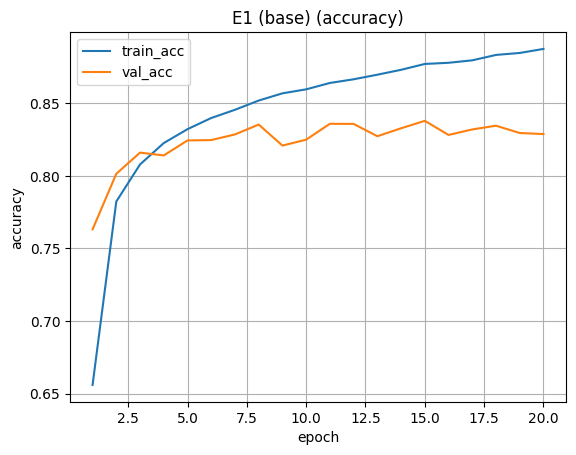

In [118]:
baseline_1 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=False).to(device) # 3 скрытых слоя

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_1.parameters(), lr=1e-3)

history_baseline_1 = fit(
    baseline_1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_1, title="E1 (base)")

In [119]:
dataset_name = "EMNIST"
log_experiment("E1", dataset_name, baseline_1, history_baseline_1, 20)

E1 сохранён в artifacts/runs.csv, best_val_acc=0.8379 (epoch 15)


### E2 (Dropout)

epoch 01/20 | train loss=1.7943, acc=0.4747 | val loss=0.9913, acc=0.6926
epoch 02/20 | train loss=1.3099, acc=0.6009 | val loss=0.8701, acc=0.7278
epoch 03/20 | train loss=1.2004, acc=0.6325 | val loss=0.7891, acc=0.7481
epoch 04/20 | train loss=1.1447, acc=0.6457 | val loss=0.7761, acc=0.7534
epoch 05/20 | train loss=1.1094, acc=0.6557 | val loss=0.7483, acc=0.7662
epoch 06/20 | train loss=1.0831, acc=0.6644 | val loss=0.7189, acc=0.7703
epoch 07/20 | train loss=1.0684, acc=0.6684 | val loss=0.7087, acc=0.7745
epoch 08/20 | train loss=1.0466, acc=0.6762 | val loss=0.7044, acc=0.7750
epoch 09/20 | train loss=1.0378, acc=0.6754 | val loss=0.6938, acc=0.7747
epoch 10/20 | train loss=1.0220, acc=0.6807 | val loss=0.6738, acc=0.7842
epoch 11/20 | train loss=1.0188, acc=0.6814 | val loss=0.6698, acc=0.7824
epoch 12/20 | train loss=1.0108, acc=0.6852 | val loss=0.6679, acc=0.7815
epoch 13/20 | train loss=1.0019, acc=0.6860 | val loss=0.6619, acc=0.7839
epoch 14/20 | train loss=0.9967, acc=0

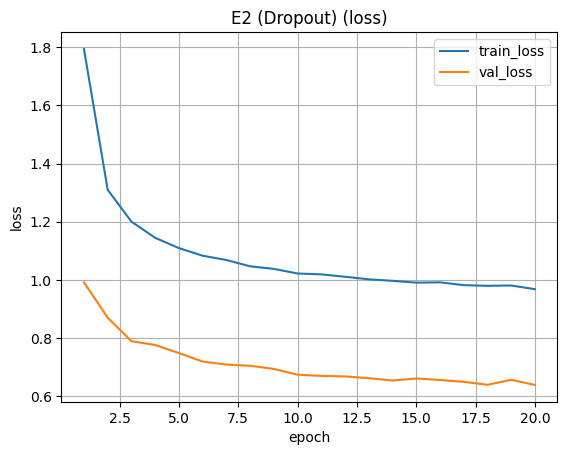

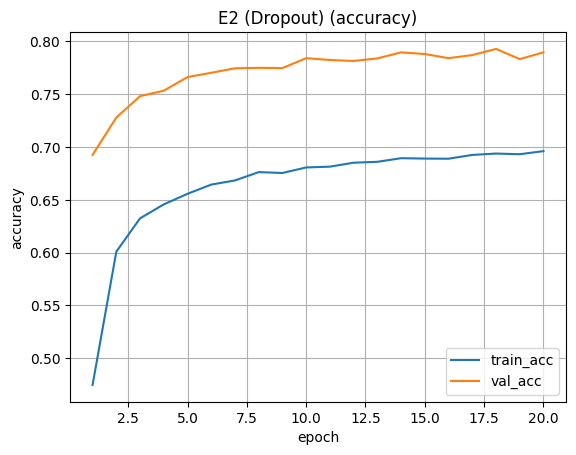

In [120]:
baseline_2 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.3, use_batchnorm=False).to(device) # 3 скрытых слоя + dropout

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_2.parameters(), lr=1e-3)

history_baseline_2 = fit(
    baseline_2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_2, title="E2 (Dropout)")

In [121]:
log_experiment("E2", dataset_name, baseline_2, history_baseline_2, 20)

E2 сохранён в artifacts/runs.csv, best_val_acc=0.7929 (epoch 18)


### E3 (BatchNorm)

epoch 01/20 | train loss=0.8923, acc=0.7362 | val loss=0.5596, acc=0.8197
epoch 02/20 | train loss=0.5427, acc=0.8161 | val loss=0.5055, acc=0.8334
epoch 03/20 | train loss=0.4743, acc=0.8357 | val loss=0.4696, acc=0.8420
epoch 04/20 | train loss=0.4331, acc=0.8480 | val loss=0.4574, acc=0.8452
epoch 05/20 | train loss=0.4036, acc=0.8554 | val loss=0.4357, acc=0.8499
epoch 06/20 | train loss=0.3817, acc=0.8621 | val loss=0.4355, acc=0.8513
epoch 07/20 | train loss=0.3622, acc=0.8670 | val loss=0.4327, acc=0.8535
epoch 08/20 | train loss=0.3441, acc=0.8718 | val loss=0.4310, acc=0.8527
epoch 09/20 | train loss=0.3299, acc=0.8765 | val loss=0.4251, acc=0.8587
epoch 10/20 | train loss=0.3185, acc=0.8796 | val loss=0.4359, acc=0.8553
epoch 11/20 | train loss=0.3065, acc=0.8833 | val loss=0.4281, acc=0.8552
epoch 12/20 | train loss=0.2973, acc=0.8859 | val loss=0.4388, acc=0.8564
epoch 13/20 | train loss=0.2875, acc=0.8884 | val loss=0.4443, acc=0.8543
epoch 14/20 | train loss=0.2772, acc=0

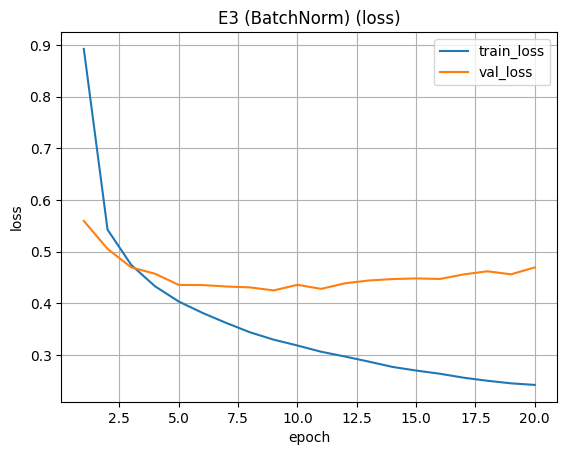

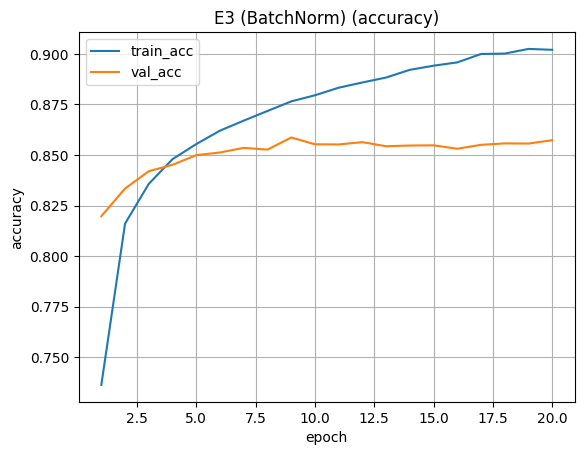

In [122]:
baseline_3 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_3.parameters(), lr=1e-3)

history_baseline_3 = fit(
    baseline_3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_3, title="E3 (BatchNorm)")

In [123]:
log_experiment("E3", dataset_name, baseline_3, history_baseline_3, 20)

E3 сохранён в artifacts/runs.csv, best_val_acc=0.8587 (epoch 9)


### E4 (EarlyStopping)

In [124]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=0.8971, acc=0.7351 | val loss=0.5720, acc=0.8121
epoch 02/20 | train loss=0.5448, acc=0.8171 | val loss=0.5133, acc=0.8287
epoch 03/20 | train loss=0.4768, acc=0.8335 | val loss=0.4810, acc=0.8402
epoch 04/20 | train loss=0.4372, acc=0.8456 | val loss=0.4668, acc=0.8451
epoch 05/20 | train loss=0.4088, acc=0.8535 | val loss=0.4553, acc=0.8447
epoch 06/20 | train loss=0.3848, acc=0.8604 | val loss=0.4407, acc=0.8530
epoch 07/20 | train loss=0.3654, acc=0.8658 | val loss=0.4366, acc=0.8529
epoch 08/20 | train loss=0.3508, acc=0.8704 | val loss=0.4430, acc=0.8531
epoch 09/20 | train loss=0.3316, acc=0.8754 | val loss=0.4324, acc=0.8559
epoch 10/20 | train loss=0.3211, acc=0.8780 | val loss=0.4304, acc=0.8578
epoch 11/20 | train loss=0.3115, acc=0.8815 | val loss=0.4481, acc=0.8555
epoch 12/20 | train loss=0.2992, acc=0.8845 | val loss=0.4394, acc=0.8564
epoch 13/20 | train loss=0.2901, acc=0.8887 | val loss=0.4486, acc=0.8563
epoch 14/20 | train loss=0.2814, acc=0

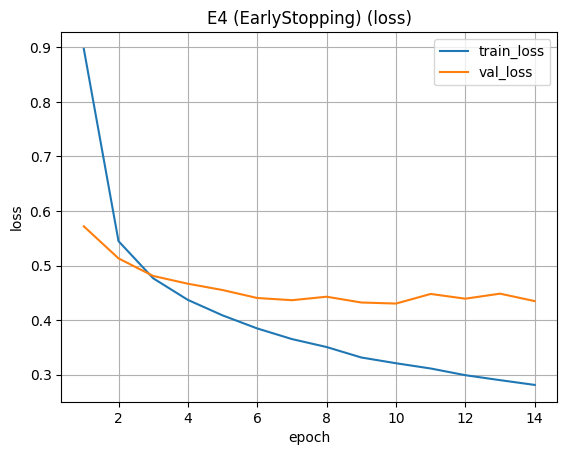

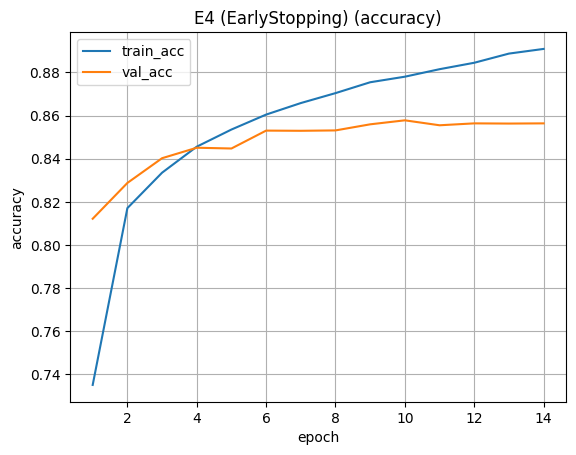

EarlyStopping test: loss=0.4488, acc=0.8530


In [125]:
baseline_4 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_4.parameters(), lr=1e-3)

history_baseline_4 = fit(
    baseline_4, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=early_stopping
)

plot_history(history_baseline_4, title="E4 (EarlyStopping)")
test_loss, test_acc = evaluate(baseline_4, test_loader, criterion, device)
print(f"EarlyStopping test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [126]:
log_experiment("E4", dataset_name, baseline_4, history_baseline_4, 20)

E4 сохранён в artifacts/runs.csv, best_val_acc=0.8578 (epoch 10)


In [127]:
torch.save(baseline_4.state_dict(), "artifacts/best_model.pt")
best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",  # замените на ваш датасет
    "seed": 19,           # ваш seed из set_seed(19)
    "model_architecture": {
        "input_dim": 28*28,
        "hidden_dims": [128, 256, 128],
        "num_classes": 47,
        "activation": "relu",
        "dropout_p": 0.0,
        "use_batchnorm": True
    },
    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": len(history_baseline_4["train_loss"]),
        "early_stopping": {
            "patience": 5,
            "min_delta": 0.001
        }
    },
    "best_val_accuracy": max(history_baseline_4["val_acc"]),
    "test_accuracy": test_acc
}

with open("artifacts/best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

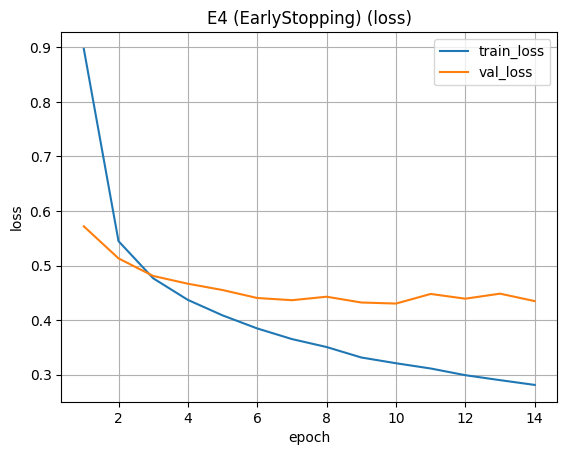

In [128]:
epochs = np.arange(1, len(history_baseline_4["train_loss"]) + 1)
title = "E4 (EarlyStopping)"

plt.figure()
plt.plot(epochs, history_baseline_4["train_loss"], label="train_loss")
plt.plot(epochs, history_baseline_4["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title((title + " (loss)") if title else "loss")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/curves_best.png")

## Часть B (S09): LR, оптимизаторы, weight decay 

### O1 (LR слишком большой)

epoch 01/8 | train loss=1.2518, acc=0.6250 | val loss=0.8460, acc=0.7301
epoch 02/8 | train loss=0.8805, acc=0.7250 | val loss=0.7774, acc=0.7406
epoch 03/8 | train loss=0.7995, acc=0.7465 | val loss=0.7355, acc=0.7570
epoch 04/8 | train loss=0.7463, acc=0.7634 | val loss=0.7300, acc=0.7682
epoch 05/8 | train loss=0.7097, acc=0.7733 | val loss=0.6274, acc=0.8046
epoch 06/8 | train loss=0.6780, acc=0.7806 | val loss=0.6000, acc=0.8051
epoch 07/8 | train loss=0.6516, acc=0.7903 | val loss=0.6145, acc=0.8122
epoch 08/8 | train loss=0.6301, acc=0.7944 | val loss=0.6107, acc=0.8137


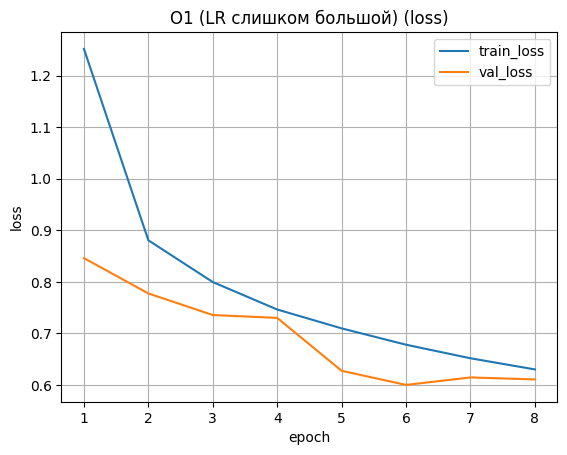

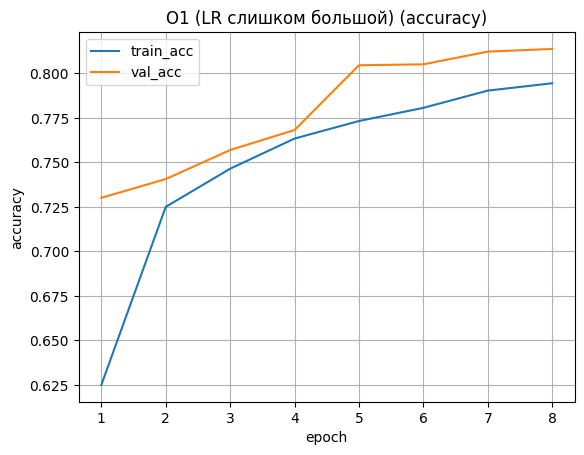

In [108]:
baseline_o1 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

optimizer_o1 = optim.Adam(baseline_o1.parameters(), lr=0.1)
history_o1 = fit(baseline_o1, train_loader, val_loader, optimizer_o1, criterion, device, epochs=8)

plot_history(history_o1, title="O1 (LR слишком большой)")

In [129]:
log_experiment("O1", dataset_name, baseline_o1, history_o1, 8, optimizer_o1)

O1 сохранён в artifacts/runs.csv, best_val_acc=0.8137 (epoch 8)


### O2 (LR слишком маленький)

epoch 01/8 | train loss=3.3897, acc=0.2198 | val loss=2.9417, acc=0.4028
epoch 02/8 | train loss=2.6747, acc=0.4714 | val loss=2.3905, acc=0.5402
epoch 03/8 | train loss=2.2251, acc=0.5683 | val loss=2.0144, acc=0.6089
epoch 04/8 | train loss=1.8920, acc=0.6201 | val loss=1.7160, acc=0.6498
epoch 05/8 | train loss=1.6383, acc=0.6555 | val loss=1.5050, acc=0.6774
epoch 06/8 | train loss=1.4422, acc=0.6805 | val loss=1.3314, acc=0.7018
epoch 07/8 | train loss=1.2901, acc=0.7019 | val loss=1.1819, acc=0.7160
epoch 08/8 | train loss=1.1719, acc=0.7180 | val loss=1.0897, acc=0.7305


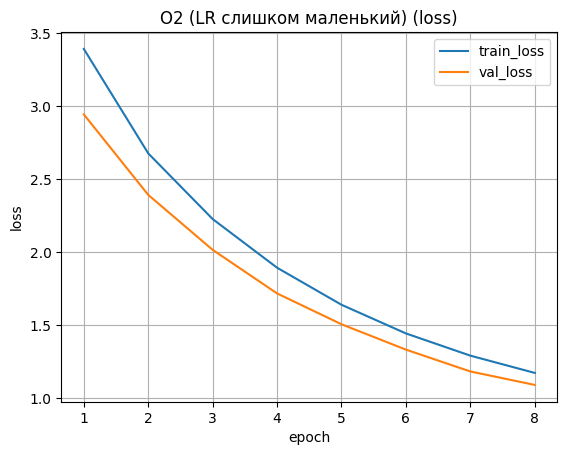

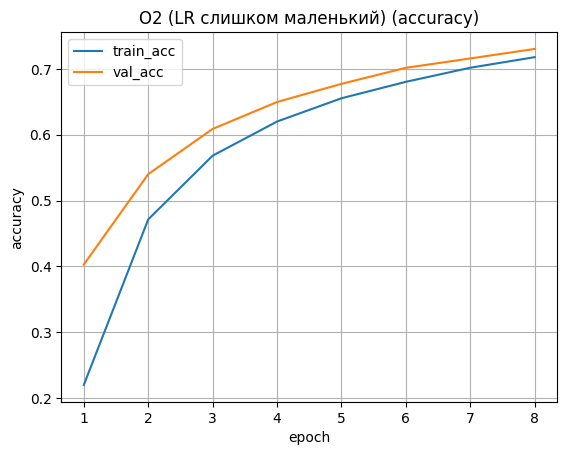

In [110]:
baseline_o2 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

optimizer_o2 = optim.Adam(baseline_o2.parameters(), lr=0.00001)
history_o2 = fit(baseline_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=8)

plot_history(history_o2, title="O2 (LR слишком маленький)")

In [130]:
log_experiment("O2", dataset_name, baseline_o2, history_o2, 8, optimizer_o2)

O2 сохранён в artifacts/runs.csv, best_val_acc=0.7305 (epoch 8)


### O3 (SGD + momentum + weight decay)

epoch 01/12 | train loss=1.8107, acc=0.5858 | val loss=1.0028, acc=0.7305
epoch 02/12 | train loss=0.8714, acc=0.7523 | val loss=0.7191, acc=0.7896
epoch 03/12 | train loss=0.6839, acc=0.7927 | val loss=0.6204, acc=0.8110
epoch 04/12 | train loss=0.5975, acc=0.8121 | val loss=0.5617, acc=0.8235
epoch 05/12 | train loss=0.5422, acc=0.8268 | val loss=0.5281, acc=0.8323
epoch 06/12 | train loss=0.5041, acc=0.8350 | val loss=0.5065, acc=0.8377
epoch 07/12 | train loss=0.4745, acc=0.8433 | val loss=0.4890, acc=0.8383
epoch 08/12 | train loss=0.4530, acc=0.8483 | val loss=0.4793, acc=0.8422
epoch 09/12 | train loss=0.4320, acc=0.8542 | val loss=0.4645, acc=0.8473
epoch 10/12 | train loss=0.4160, acc=0.8580 | val loss=0.4600, acc=0.8469
epoch 11/12 | train loss=0.3999, acc=0.8628 | val loss=0.4567, acc=0.8490
epoch 12/12 | train loss=0.3864, acc=0.8657 | val loss=0.4516, acc=0.8482


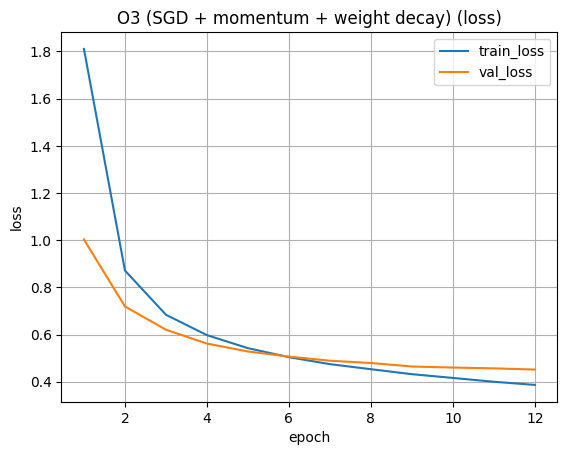

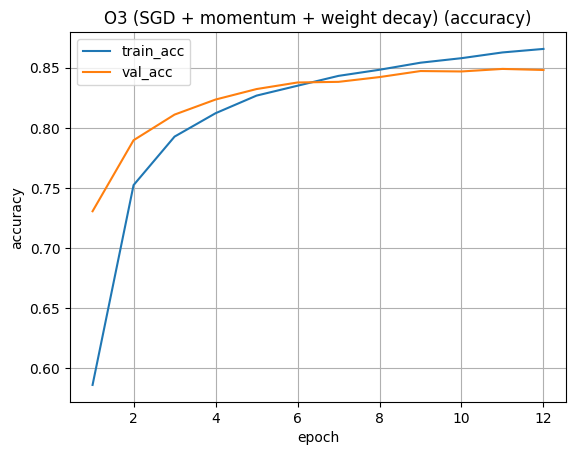

In [104]:
baseline_o3 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

optimizer_o3 = optim.SGD(baseline_o3.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
history_o3 = fit(baseline_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=12)

plot_history(history_o3, title="O3 (SGD + momentum + weight decay)")

In [131]:
log_experiment("O3", dataset_name, baseline_o3, history_o3, 12, optimizer_o3)

O3 сохранён в artifacts/runs.csv, best_val_acc=0.8490 (epoch 11)


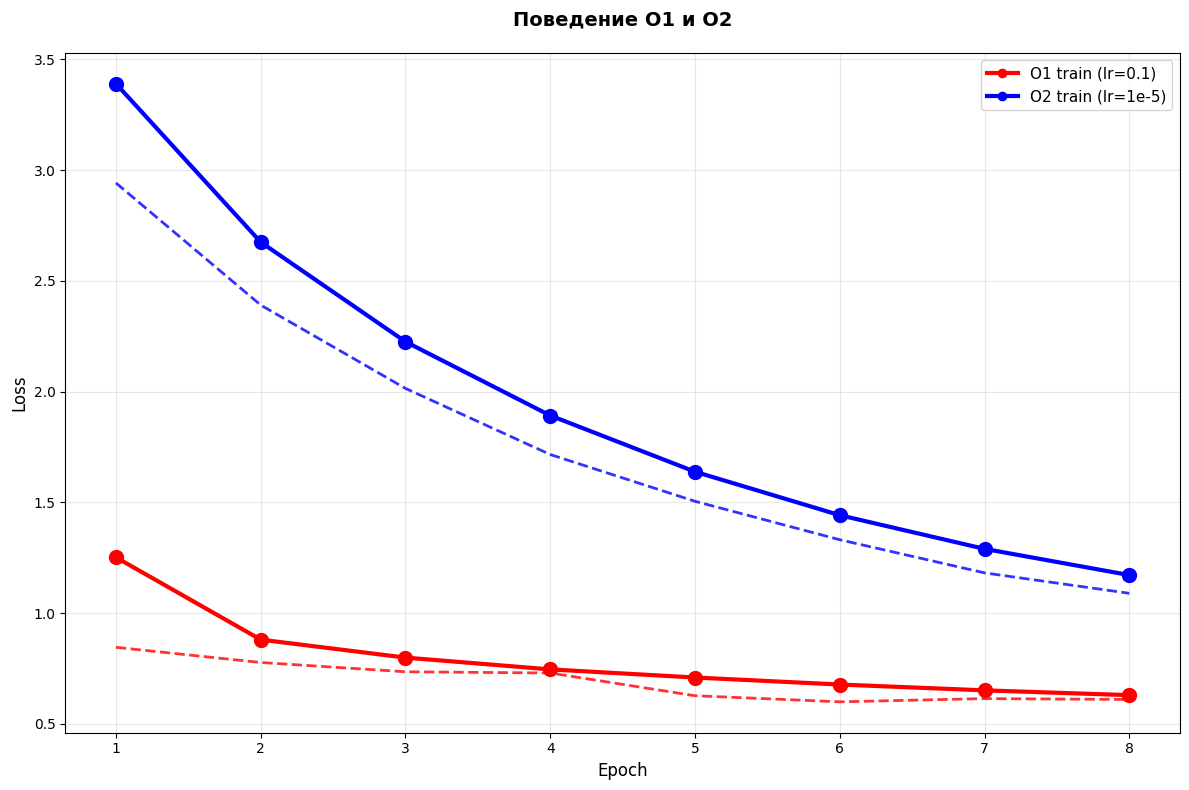

In [114]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Нормализуем эпохи для наложения
max_epochs = max(len(history_o1["train_loss"]), len(history_o2["train_loss"]))
epochs_o1 = np.arange(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = np.arange(1, len(history_o2["train_loss"]) + 1)

# O1 (lr=0.1)
ax.plot(epochs_o1, history_o1["train_loss"], 'r-o', label="O1 train (lr=0.1)", linewidth=3, markersize=6)
ax.plot(epochs_o1, history_o1["val_loss"], 'r--', alpha=0.8, linewidth=2)
ax.scatter(epochs_o1, history_o1["train_loss"], color='red', s=100, zorder=5)

# O2 (lr=1e-5)
ax.plot(epochs_o2, history_o2["train_loss"], 'b-o', label="O2 train (lr=1e-5)", linewidth=3, markersize=6)
ax.plot(epochs_o2, history_o2["val_loss"], 'b--', alpha=0.8, linewidth=2)
ax.scatter(epochs_o2, history_o2["train_loss"], color='blue', s=100, zorder=5)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Поведение O1 и O2", 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")

In [117]:
import sys
print('python:', sys.version)
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)

python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
